In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# opening file
df = pd.read_csv("Data.csv")
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Cleaning Dataset

Before Doing cleaning and EDA I physically visited the dataset with excel there i found datas are separated by rural and urban Area and in between them the NaN rows are present 

In [3]:
df.shape

(768, 7)

In [4]:
df.size

5376

In [5]:
df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [6]:
df.tail(14)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.dropna(how="all" , inplace=True)

What I did there ? I drop all the rows those are fully blank or nan not for a single values, after that i saw the all null values are gone

In [8]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [9]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


------------- After Seeing the described version of data i think ther are outliers in my data in column Estimated Unemployment Rate (%) ----------------

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 46.2+ KB


After checking Data info I can see Data Type of Date is not in format 

In [11]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [12]:
df.duplicated().sum()

0

In [13]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Date']

0     2019-05-31
1     2019-06-30
2     2019-07-31
3     2019-08-31
4     2019-09-30
         ...    
749   2020-02-29
750   2020-03-31
751   2020-04-30
752   2020-05-31
753   2020-06-30
Name: Date, Length: 740, dtype: datetime64[ns]

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [15]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,740,2019-12-12 18:36:58.378378496,2019-05-31 00:00:00,2019-08-31 00:00:00,2019-11-30 00:00:00,2020-03-31 00:00:00,2020-06-30 00:00:00,NaN
Estimated Unemployment Rate (%),740.0,11.787946,0.0,4.6575,8.35,15.8875,76.74,10.721298
Estimated Employed,740.0,7204460.025676,49420.0,1190404.5,4744178.5,11275489.5,45777509.0,8087988.429458
Estimated Labour Participation Rate (%),740.0,42.630122,13.33,38.0625,41.16,45.505,72.57,8.111094


In [16]:
df.shape

(740, 7)

Now shape changed from 768 to 740 rows are here only.

In [17]:
df.size

5180

Fixed Column name

### Handeling catagorical values

In [18]:
df['Frequency'].nunique()

2

In [19]:
df['Frequency'].unique()

array([' Monthly', 'Monthly'], dtype=object)

In [20]:
df["Frequency"] = df["Frequency"].str.strip()

In [21]:
df['Frequency'].nunique()

1

------- After checking for catagorical values at Frequecy, There are only 1 distinct value is present in the whole column so I should drop it, Noise Data. -------

In [22]:
df.drop(columns=['Frequency'], inplace=True)

In [23]:
for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].nunique())
    print(col, ":", df[col].unique())

Region : 28
Region : ['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']
Area : 2
Area : ['Rural' 'Urban']


------Checking for outliers-----

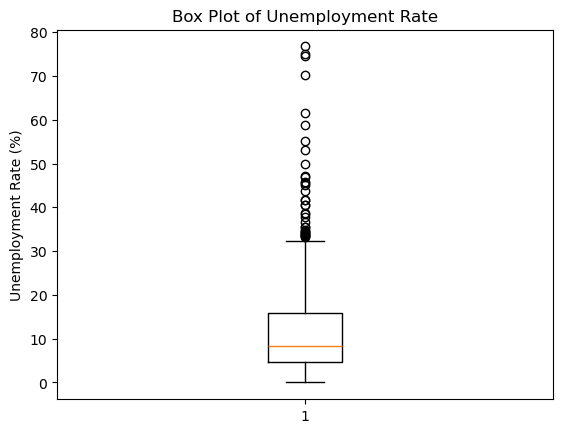

In [24]:
plt.boxplot(df['Estimated Unemployment Rate (%)'])
plt.ylabel('Unemployment Rate (%)')
plt.title('Box Plot of Unemployment Rate')
plt.show()

No I think I should not delete outliers data, let it be. It is possible during lockdown period Unemployement rate had a high spike.

In [25]:
# Exactly when the outliers occurred
q3 = df['Estimated Unemployment Rate (%)'].quantile(0.75)
iqr = df['Estimated Unemployment Rate (%)'].quantile(0.75) - df['Estimated Unemployment Rate (%)'].quantile(0.25)

outliers = df[df['Estimated Unemployment Rate (%)'] > q3 + 1.5 * iqr]
print(outliers[['Date', 'Estimated Unemployment Rate (%)']].sort_values('Estimated Unemployment Rate (%)', ascending=False))

          Date  Estimated Unemployment Rate (%)
627 2020-04-30                            76.74
628 2020-05-31                            75.00
242 2020-04-30                            74.51
531 2020-05-31                            70.17
530 2020-04-30                            61.48
412 2020-04-30                            58.77
145 2020-05-31                            55.10
287 2020-04-30                            53.19
507 2020-05-31                            50.00
38  2020-05-31                            47.26
492 2020-04-30                            46.89
453 2020-05-31                            45.78
681 2020-04-30                            45.55
37  2020-04-30                            45.09
315 2020-04-30                            43.64
144 2020-04-30                            41.72
105 2020-04-30                            41.61
255 2020-05-31                            40.59
573 2020-05-31                            40.49
288 2020-05-31                          

# EDA - Exploratory Data Analysis

In [26]:
# Before Plotting Graph I think Ishould separate the dataframes
rural_df = df[df['Area'] == 'Rural'].copy()

urban_df = df[df['Area'] == 'Urban'].copy()

In [27]:
np.shape(rural_df)

(359, 6)

In [28]:
np.shape(urban_df)

(381, 6)

In [29]:
rural_df.sample(5)

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
254,Punjab,2020-04-30,3.69,4721590.0,32.20,Rural
267,Rajasthan,2020-03-31,9.47,15059769.0,39.47,Rural
8,Andhra Pradesh,2020-01-31,4.84,12016676.0,43.46,Rural
318,Uttar Pradesh,2019-05-31,10.26,43287808.0,39.96,Rural
197,Maharashtra,2020-01-31,3.80,25881398.0,50.36,Rural


### Distribution

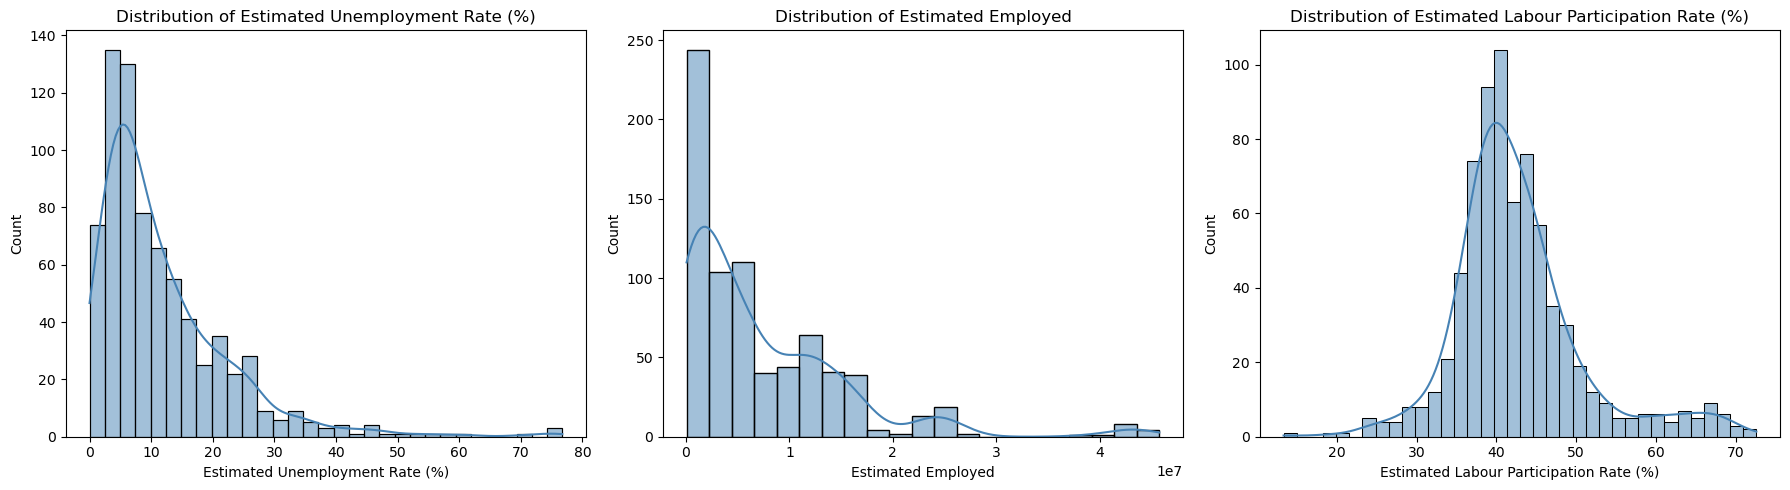

In [30]:
# Distribution for Numerical Columns
num_cols = ['Estimated Unemployment Rate (%)', 
            'Estimated Employed', 
            'Estimated Labour Participation Rate (%)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig('Distributions.png')
plt.show()

### Visuals of Indivisual

In [31]:
# Sorting date column for better indivisual graphs
rural_df['Date'] = rural_df['Date'].sort_index(ascending=False)
rural_df['Date']

0     2019-05-31
1     2019-06-30
2     2019-07-31
3     2019-08-31
4     2019-09-30
         ...    
354   2020-02-29
355   2020-03-31
356   2020-04-30
357   2020-05-31
358   2020-06-30
Name: Date, Length: 359, dtype: datetime64[ns]

In [32]:
urban_df['Date'] = urban_df['Date'].sort_index(ascending=False)
urban_df['Date']

373   2019-05-31
374   2019-06-30
375   2019-07-31
376   2019-08-31
377   2019-09-30
         ...    
749   2020-02-29
750   2020-03-31
751   2020-04-30
752   2020-05-31
753   2020-06-30
Name: Date, Length: 381, dtype: datetime64[ns]

In [33]:
rural_monthly = (
    rural_df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
)

urban_monthly = (
    urban_df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
)

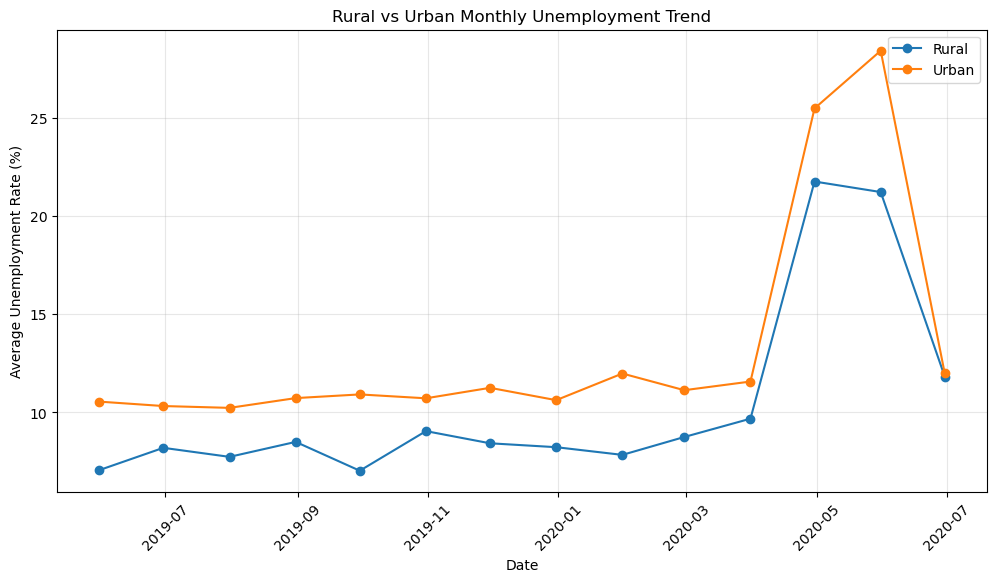

In [34]:
# Distribution for catagorical columns
plt.figure(figsize=(12, 6))
plt.plot(
    rural_monthly.index,
    rural_monthly.values,
    marker='o',
    label='Rural'
)
plt.plot(
    urban_monthly.index,
    urban_monthly.values,
    marker='o',
    label='Urban'
)

plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Rural vs Urban Monthly Unemployment Trend')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('Trend_Rural_VS_Urban.png')
plt.show()

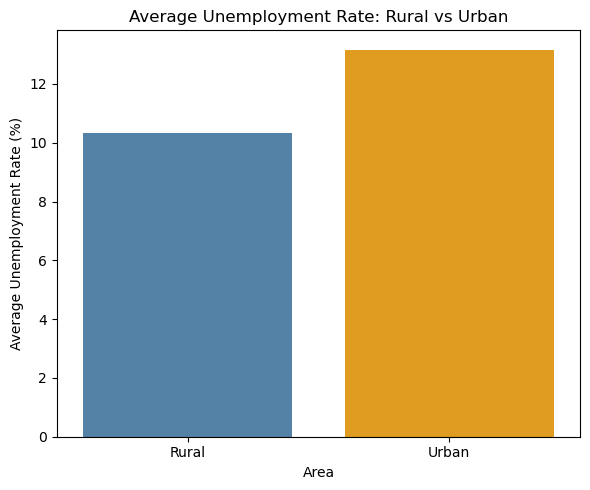

In [35]:
# 2 separated Bars Urban & Rural Unemployement
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=area_avg, x='Area', y='Estimated Unemployment Rate (%)',hue='Area', palette=['steelblue', 'orange'], legend=False)

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('Barplot_avr_UnemoplymentRate.png')
plt.show()

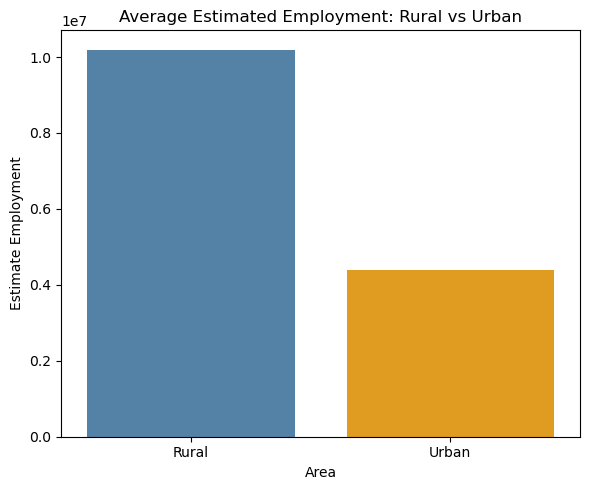

In [36]:
# 2 separated Bars Urban & Rural Employement

area_avg = df.groupby('Area')['Estimated Employed'].mean().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=area_avg, x='Area', y='Estimated Employed',  hue='Area', palette=['steelblue', 'orange'], legend=False)

plt.title('Average Estimated Employment: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Estimate Employment')
plt.tight_layout()
plt.savefig('Barplot_Estimate Employment.png')
plt.show()

### Combined Visuals

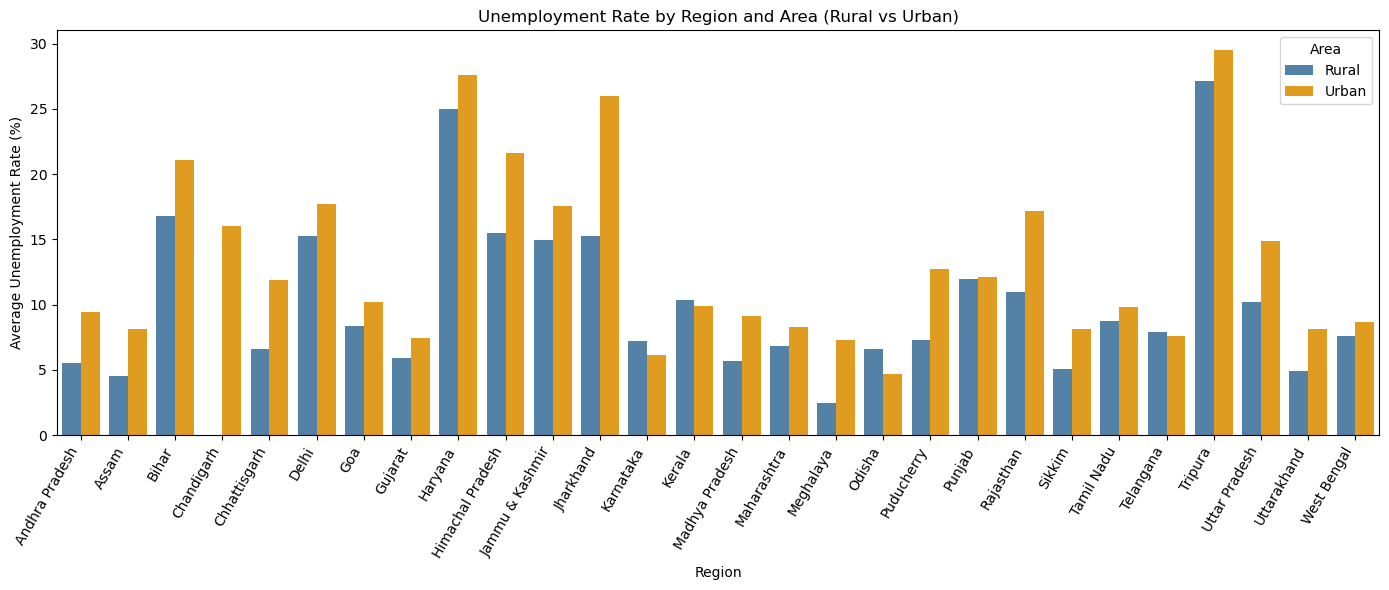

In [37]:
# Group by Region and Area
region_area = df.groupby(['Region', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=region_area, x='Region', y='Estimated Unemployment Rate (%)', hue='Area', palette=['steelblue', 'orange'],errorbar=None)

plt.title('Unemployment Rate by Region and Area (Rural vs Urban)')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Area')
plt.tight_layout()
plt.savefig("Barplot_Unemployment_Rate_Region_VS_Area.png")
plt.show()

At first glance, **Chhattisgarh's** bar almost looks like it has
only Urban data. But that's not true.
Both Rural and Urban data are present — **14** entries each.
The Rural bar is just so much shorter **(~6%)** compared to
Urban **(~11%)** that it barely catches the eye.
Why exactly this gap exists — I can't say for sure.
Maybe urban job markets in Chhattisgarh are more stressed.
Maybe rural workers are absorbed into agriculture and
don't show up as "unemployed" in the numbers.


In [38]:
# Check Chhattisgarh data
cg = df[df['Region'] == 'Chhattisgarh']
print("Total rows:", len(cg))
print("\nArea types present:")
print(cg['Area'].value_counts())
print("\nSample data:")
print(cg[['Region', 'Date', 'Area']].head(10))

Total rows: 28

Area types present:
Area
Rural    14
Urban    14
Name: count, dtype: int64

Sample data:
          Region       Date   Area
40  Chhattisgarh 2019-05-31  Rural
41  Chhattisgarh 2019-06-30  Rural
42  Chhattisgarh 2019-07-31  Rural
43  Chhattisgarh 2019-08-31  Rural
44  Chhattisgarh 2019-09-30  Rural
45  Chhattisgarh 2019-10-31  Rural
46  Chhattisgarh 2019-11-30  Rural
47  Chhattisgarh 2019-12-31  Rural
48  Chhattisgarh 2020-01-31  Rural
49  Chhattisgarh 2020-02-29  Rural


In [39]:
print(cg.groupby('Area')['Estimated Unemployment Rate (%)'].mean())

Area
Rural     6.628571
Urban    11.852143
Name: Estimated Unemployment Rate (%), dtype: float64


In [40]:
# Check Delhi data
dl = df[df['Region'] == 'Delhi']
print("Total rows:", len(dl))
print("\nArea types present:")
print(dl['Area'].value_counts())
print("\nSample data:")
print(dl[['Region', 'Date', 'Area']].head(10))

Total rows: 28

Area types present:
Area
Rural    14
Urban    14
Name: count, dtype: int64

Sample data:
   Region       Date   Area
54  Delhi 2019-05-31  Rural
55  Delhi 2019-06-30  Rural
56  Delhi 2019-07-31  Rural
57  Delhi 2019-08-31  Rural
58  Delhi 2019-09-30  Rural
59  Delhi 2019-10-31  Rural
60  Delhi 2019-11-30  Rural
61  Delhi 2019-12-31  Rural
62  Delhi 2020-01-31  Rural
63  Delhi 2020-02-29  Rural


In [41]:
print(dl.groupby('Area')['Estimated Unemployment Rate (%)'].mean())

Area
Rural    15.258571
Urban    17.732143
Name: Estimated Unemployment Rate (%), dtype: float64


In [42]:
df["Date"].unique()

<DatetimeArray>
['2019-05-31 00:00:00', '2019-06-30 00:00:00', '2019-07-31 00:00:00',
 '2019-08-31 00:00:00', '2019-09-30 00:00:00', '2019-10-31 00:00:00',
 '2019-11-30 00:00:00', '2019-12-31 00:00:00', '2020-01-31 00:00:00',
 '2020-02-29 00:00:00', '2020-03-31 00:00:00', '2020-04-30 00:00:00',
 '2020-05-31 00:00:00', '2020-06-30 00:00:00']
Length: 14, dtype: datetime64[ns]

Only 2 years are there 2019 and 2020. So I'm goin to plot two different visuals for them.

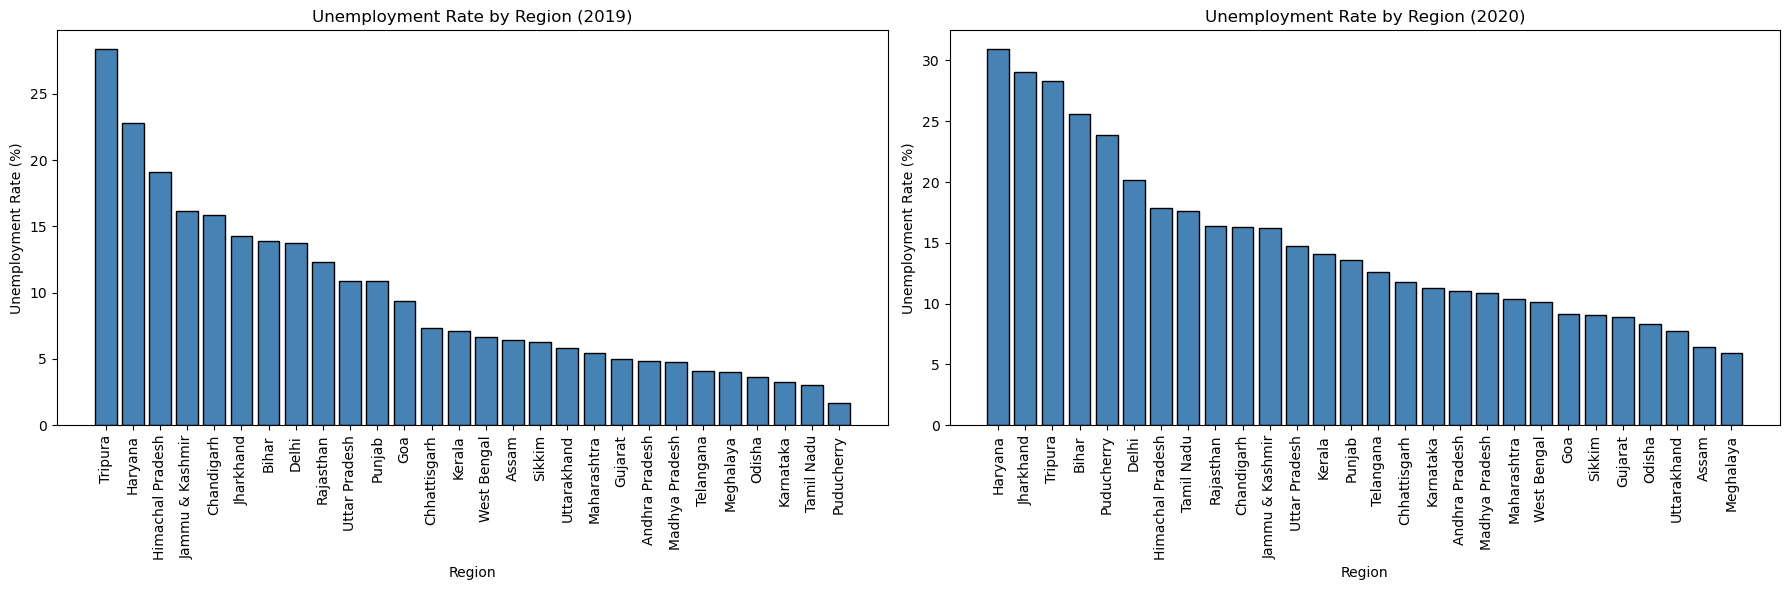

In [43]:
# Split by year
df['Year'] = df['Date'].dt.year
df_2019 = df[df['Year'] == 2019] # making seperate columns
df_2020 = df[df['Year'] == 2020]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (year, data) in zip(axes, [(2019, df_2019), (2020, df_2020)]):
    region_data = data.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
    ax.bar(region_data.index, region_data.values, color='steelblue', edgecolor='black')
    ax.set_title(f'Unemployment Rate by Region ({year})')
    ax.set_xlabel('Region')
    ax.set_ylabel('Unemployment Rate (%)')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig("BarSubplots_Unemployment_rate_2019_and_2020.png")
plt.show()

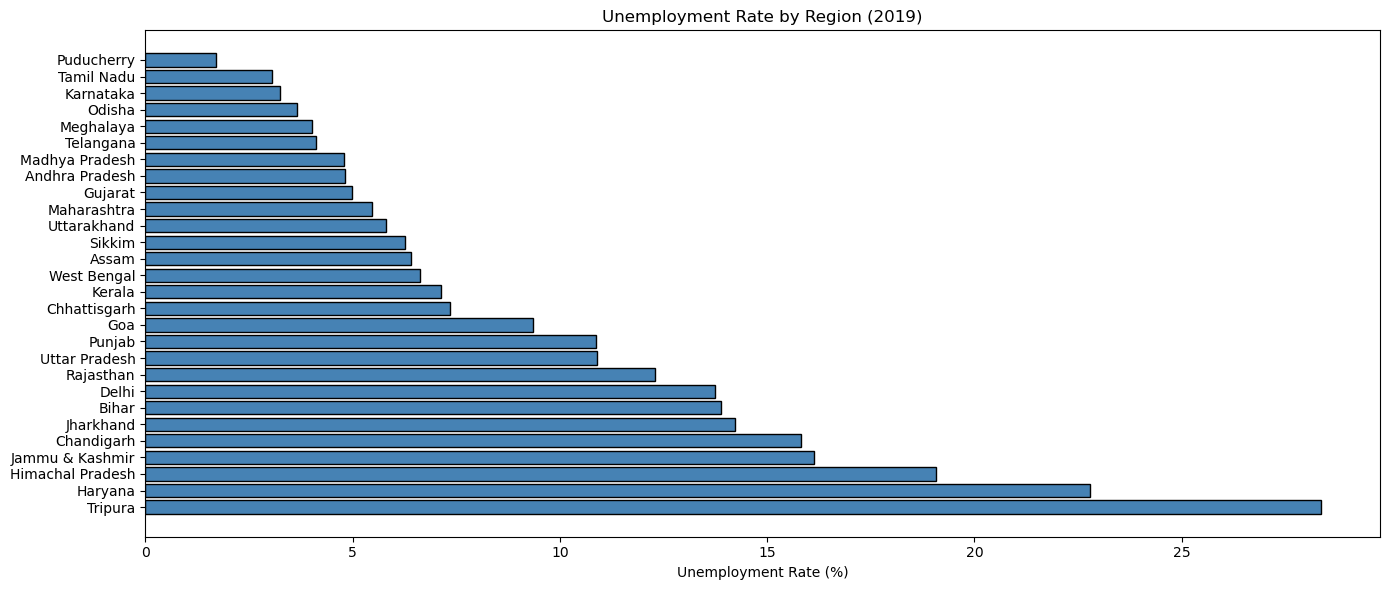

In [44]:
df['Year'] = df['Date'].dt.year
# Chart 1 — 2019
region_2019 = df_2019.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
plt.barh(region_2019.index, region_2019.values, color='steelblue', edgecolor='black')
plt.title('Unemployment Rate by Region (2019)')
plt.xlabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

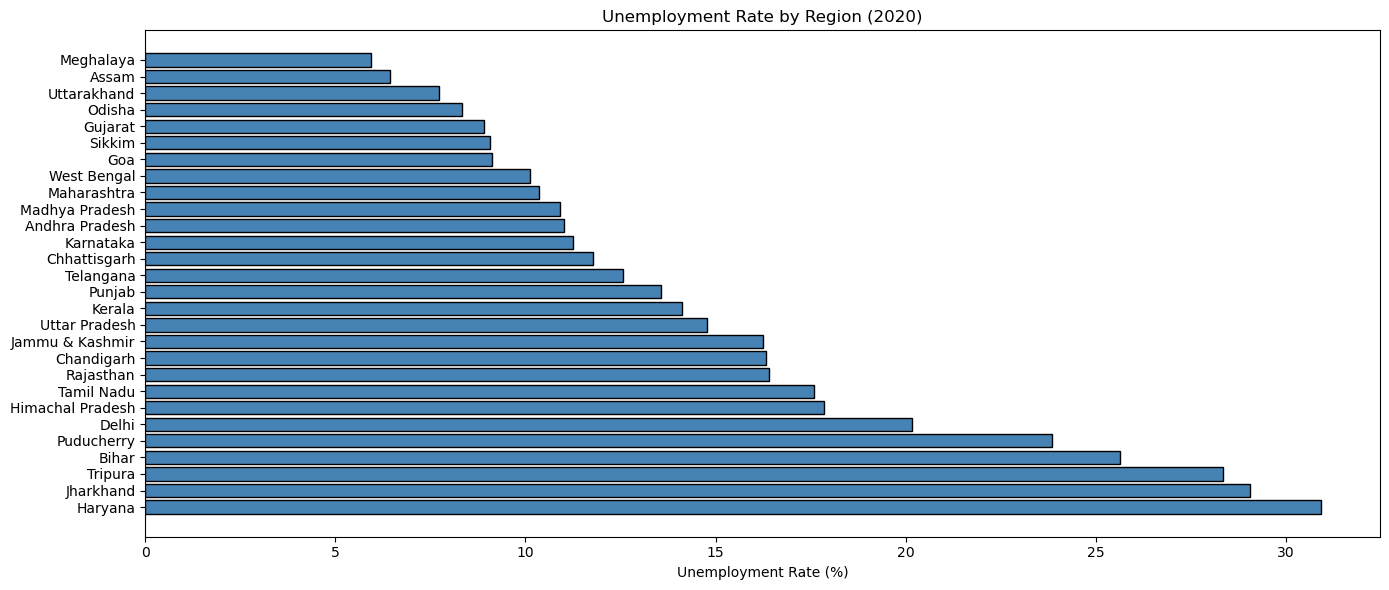

In [45]:
# Chart 2 — 2020
region_2020 = df_2020.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
plt.barh(region_2020.index, region_2020.values,color='steelblue', edgecolor='black')
plt.title('Unemployment Rate by Region (2020)')
plt.xlabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

### Top 10 State with highest avg Unemployment

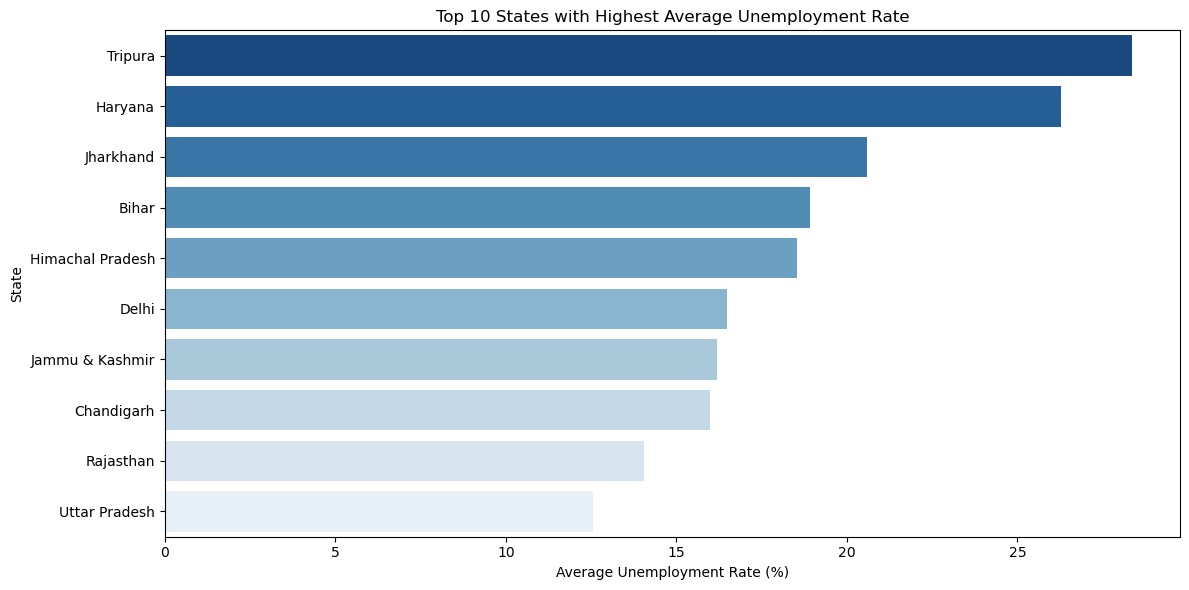

In [46]:
top10 = (df.groupby('Region')['Estimated Unemployment Rate (%)'].mean())
top10 = top10.sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='Estimated Unemployment Rate (%)', y='Region',hue = 'Region',palette='Blues_r' , legend = False)

plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig("Barplt_Top_Unemployment_TOP_10_State.png")
plt.show()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Estimated Unemployment Rate (%)          740 non-null    float64       
 3   Estimated Employed                       740 non-null    float64       
 4   Estimated Labour Participation Rate (%)  740 non-null    float64       
 5   Area                                     740 non-null    object        
 6   Year                                     740 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(1), object(2)
memory usage: 43.4+ KB


### Making a new column

In [48]:
df["Employment rate (%)"] = 100 - df["Estimated Unemployment Rate (%)"]

In [49]:
df

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Employment rate (%)
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural,2019,96.35
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural,2019,96.95
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural,2019,96.25
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural,2019,96.68
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural,2019,94.83
...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,7.55,10871168.0,44.09,Urban,2020,92.45
750,West Bengal,2020-03-31,6.67,10806105.0,43.34,Urban,2020,93.33
751,West Bengal,2020-04-30,15.63,9299466.0,41.20,Urban,2020,84.37
752,West Bengal,2020-05-31,15.22,9240903.0,40.67,Urban,2020,84.78


### Heatmap: correlation between unemployment rate, employment rate, and labour participation rate

In [50]:
corr2 = df[['Estimated Unemployment Rate (%)','Estimated Employed','Estimated Labour Participation Rate (%)']].corr()
corr2

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


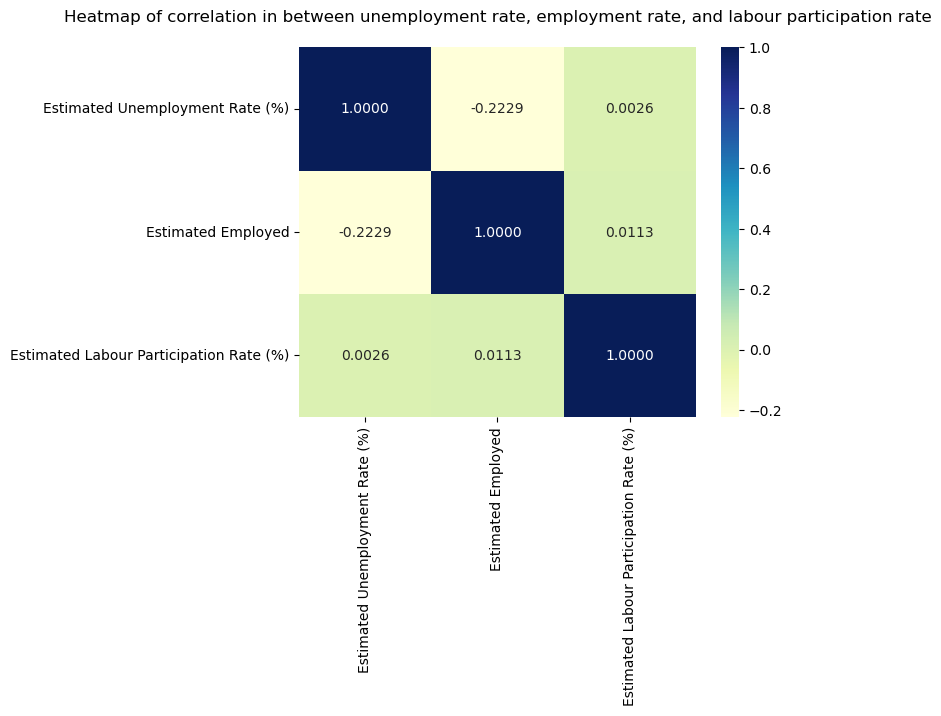

In [51]:
sns.heatmap(corr2, annot=True, fmt=".4f", cmap='YlGnBu') 
plt.title('Heatmap of correlation in between unemployment rate, employment rate, and labour participation rate\n  ') 
plt.savefig("Heatmap_Correlation")
plt.show() 

Rural and Urban data are mixed here so a suspisious result is coming.

### Making Heatmap rtln for Urban & Rural

In [52]:
rural_df["Rural Employment rate (%)"] = 100 - rural_df["Estimated Unemployment Rate (%)"]

In [53]:
urban_df["Urban Employment rate (%)"] = 100 - urban_df["Estimated Unemployment Rate (%)"]

In [54]:
corr_rural2 = rural_df[['Estimated Unemployment Rate (%)','Rural Employment rate (%)','Estimated Labour Participation Rate (%)']].corr()
corr_rural2

,Estimated Unemployment Rate (%),Rural Employment rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-1.000000,-0.020124
Rural Employment rate (%),-1.000000,1.000000,0.020124
Estimated Labour Participation Rate (%),-0.020124,0.020124,1.000000


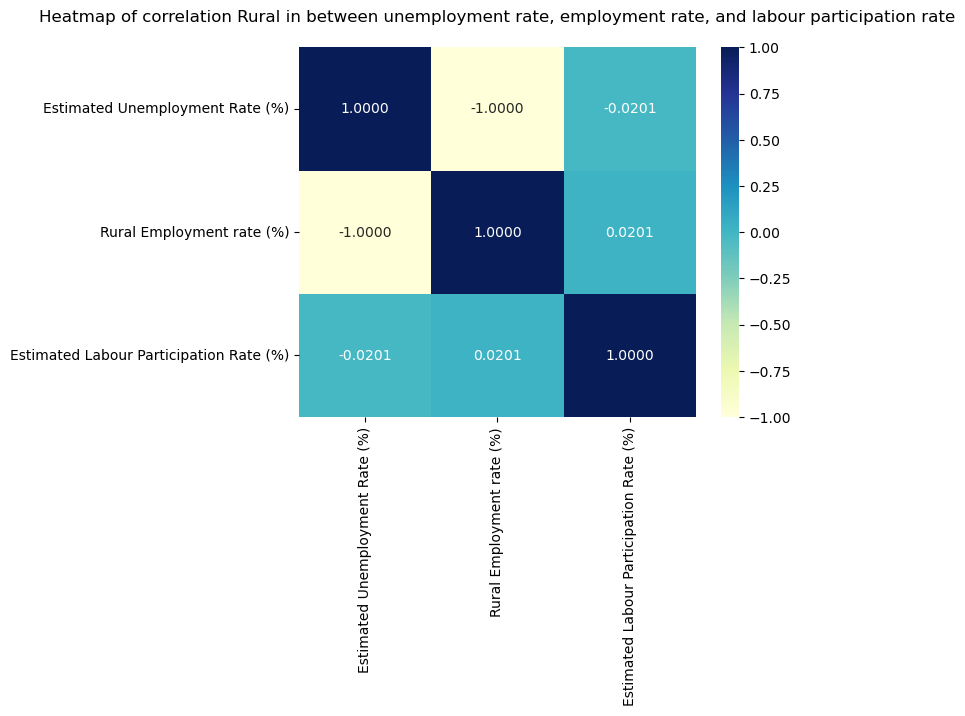

In [55]:
# Rural Correlation plot
sns.heatmap(corr_rural2, annot=True, fmt=".4f", cmap='YlGnBu') 
plt.title('Heatmap of correlation Rural in between unemployment rate, employment rate, and labour participation rate\n  ') 
plt.savefig("Heatmap_Correlation_Rural")
plt.show() 

The correlation matrix reveals that Labour Participation Rate has a near-zero correlation with both Unemployment Rate (-0.02) and Employment Rate (+0.02) in Rural areas. This suggests that in India's rural economy, labour participation is driven by structural and seasonal factors (agricultural cycles, government schemes like MGNREGA) rather than unemployment levels alone. The perfect -1.0 between Unemployment and Employment Rate is mathematically expected by derivation. The -1.0 between Unemployment Rate and Employment Rate is mathematically expected since one is derived directly from the other.

In [56]:
corr_urban2 = urban_df[['Estimated Unemployment Rate (%)','Urban Employment rate (%)','Estimated Labour Participation Rate (%)']].corr()
corr_urban2

,Estimated Unemployment Rate (%),Urban Employment rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-1.000000,0.091123
Urban Employment rate (%),-1.000000,1.000000,-0.091123
Estimated Labour Participation Rate (%),0.091123,-0.091123,1.000000


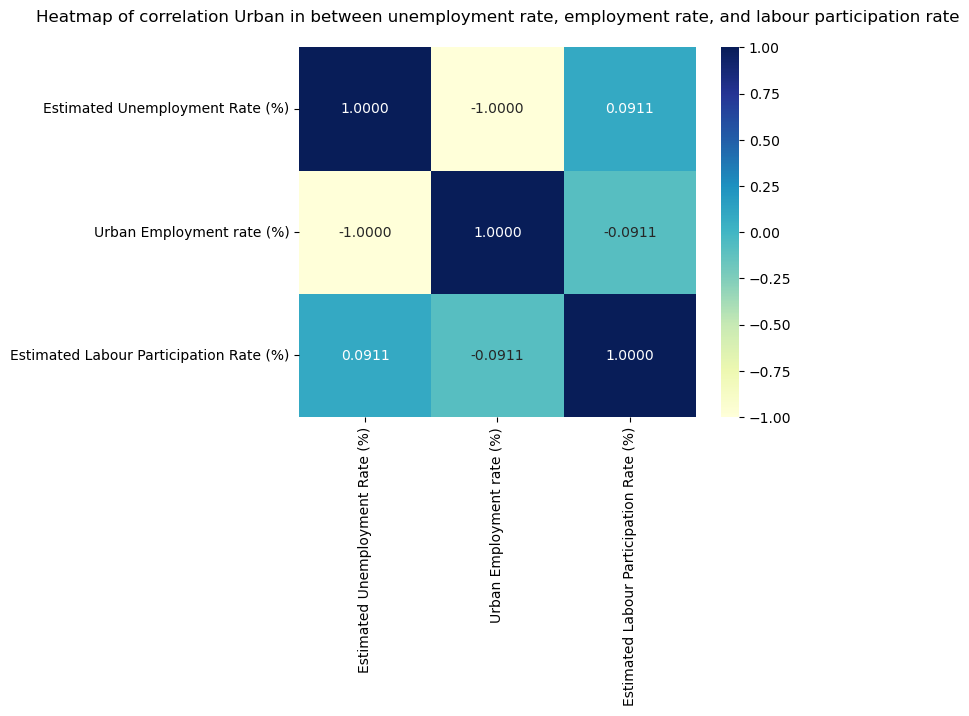

In [57]:
# Urban Correlation plot
sns.heatmap(corr_urban2, annot=True, fmt=".4f", cmap='YlGnBu') 
plt.title('Heatmap of correlation Urban in between unemployment rate, employment rate, and labour participation rate\n  ') 
plt.savefig("Heatmap_Correlation_Urban")
plt.show() 

No strong correlation was found between Labour Participation and Unemployment. In **Rural areas** — when jobs disappear, people stop looking.They give up. Thats the discouragement showing.In **Urban areas** — when one person loses a job, someone else in thefamily steps up and starts looking for work. The -1.0 between Unemployment Rate and Employment Rate is mathematically expected since one is derived directly from the other.

### Pre vs Post Covid Split

In [58]:
# Pre-COVID vs During-COVID Comparison
# Data slpiting
pre_covid  = df[df['Date'] < '2020-04-01']   #May 2019 to March 2020
during_covid = df[df['Date'] >= '2020-04-01']  # April 2020- June 2020

# Meann rate each period
comparison = pd.DataFrame({
    'Pre-COVID (May 2019 - Mar 2020)': pre_covid[['Estimated Unemployment Rate (%)',
                                                    'Estimated Labour Participation Rate (%)']].mean(),
    'During COVID (Apr 2020 - Jun 2020)': during_covid[['Estimated Unemployment Rate (%)',
                                                       'Estimated Labour Participation Rate (%)']].mean()
})

print(comparison.round(2))

                                         Pre-COVID (May 2019 - Mar 2020)  \
Estimated Unemployment Rate (%)                                     9.61   
Estimated Labour Participation Rate (%)                            43.82   

                                         During COVID (Apr 2020 - Jun 2020)  
Estimated Unemployment Rate (%)                                       20.19  
Estimated Labour Participation Rate (%)                               38.05  


### VISUALIZATION

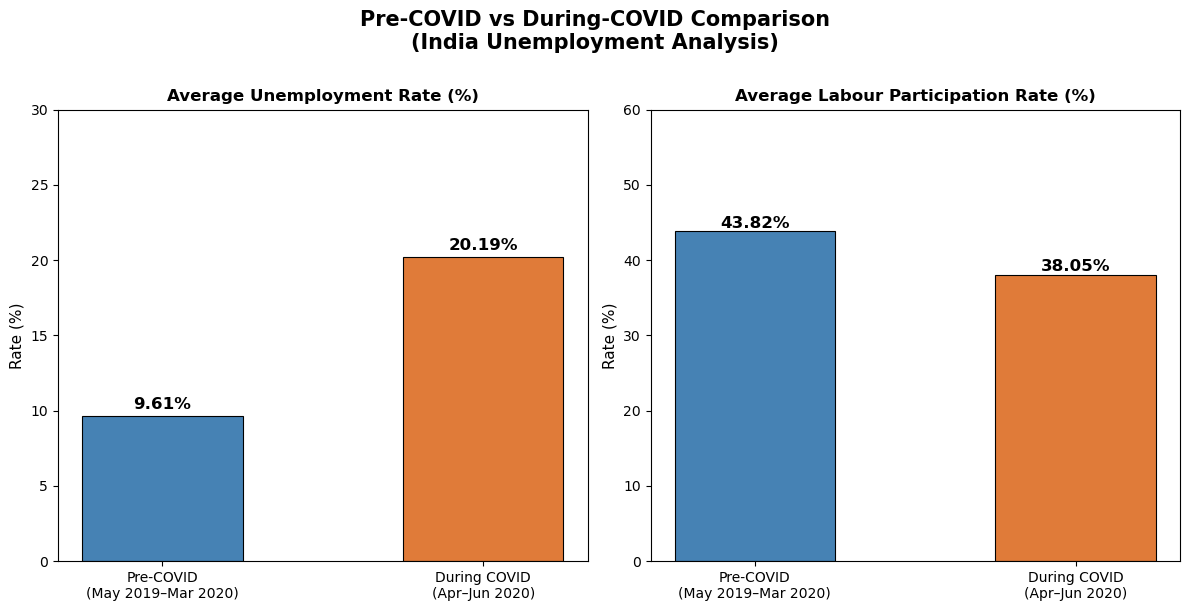

In [59]:
# Step 2: Calculate mean rates
metrics = ['Estimated Unemployment Rate (%)', 'Estimated Labour Participation Rate (%)']

pre_means    = pre_covid[metrics].mean()
during_means = during_covid[metrics].mean()

# Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Pre-COVID vs During-COVID Comparison\n(India Unemployment Analysis)',
             fontsize=15, fontweight='bold', y=1.01)

colors = ['steelblue', '#E07B39']   # Blue = Pre, ornage = During COVID
labels = ['Pre-COVID\n(May 2019–Mar 2020)', 'During COVID\n(Apr–Jun 2020)']

# Plot 1: Unemployment Rate ──
axes[0].bar(labels,
            [pre_means['Estimated Unemployment Rate (%)'],
             during_means['Estimated Unemployment Rate (%)']],
            color=colors, edgecolor='black', linewidth=0.8, width=0.5)

axes[0].set_title('Average Unemployment Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rate (%)', fontsize=11)
axes[0].set_ylim(0, 30)

for i, val in enumerate([pre_means['Estimated Unemployment Rate (%)'],
                          during_means['Estimated Unemployment Rate (%)']]):
    axes[0].text(i, val + 0.5, f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

axes[1].bar(labels,
            [pre_means['Estimated Labour Participation Rate (%)'],
             during_means['Estimated Labour Participation Rate (%)']],
            color=colors, edgecolor='black', linewidth=0.8, width=0.5)

axes[1].set_title('Average Labour Participation Rate (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rate (%)', fontsize=11)
axes[1].set_ylim(0, 60)

for i, val in enumerate([pre_means['Estimated Labour Participation Rate (%)'],
                          during_means['Estimated Labour Participation Rate (%)']]):
    axes[1].text(i, val + 0.5, f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('PreCOVID_vs_DuringCOVID_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Unemployment**
Unemployment nearly doubled
Before COVID it was **9.61%**. During COVID it jumped to **20.19%**.
**Labour Participation.**
It dropped from **43.82%** to **38.05%** — dropped by **6 percentage**.
This means people lose jobs alltogether.

### Time-series linechart

In [60]:
#Time-Series Line Chart: Unemployment Rate Over Time (Major States)

major_states = ['Maharashtra', 'Delhi', 'Uttar Pradesh', 'Rajasthan', 'West Bengal']

ts_df = (
    df[df['Region'].isin(major_states)]
    .groupby(['Region', 'Date'])['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)



### Visuals

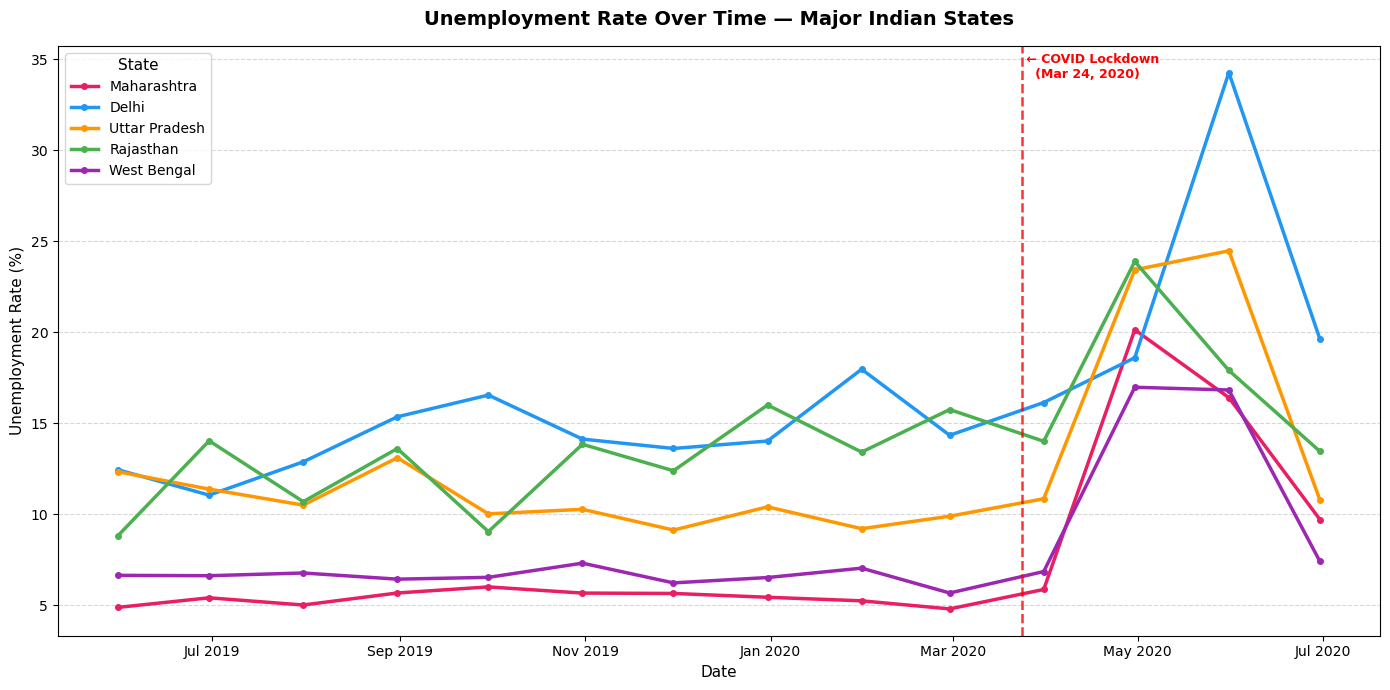

In [61]:

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#E91E63', '#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

for color, state in zip(colors, major_states):
    state_data = ts_df[ts_df['Region'] == state].sort_values('Date')
    ax.plot(state_data['Date'],
            state_data['Estimated Unemployment Rate (%)'],
            label=state,
            color=color,
            linewidth=2.5,
            marker='o',
            markersize=4)

# Step 4: Mark COVID lockdown line
import matplotlib.dates as mdates
lockdown_date = pd.Timestamp('2020-03-24')

ax.axvline(x=lockdown_date, color='red', linestyle='--', linewidth=1.8, alpha=0.8)
ax.text(lockdown_date, ax.get_ylim()[1] * 0.95,
        ' ← COVID Lockdown\n   (Mar 24, 2020)',
        color='red', fontsize=9, fontweight='bold')

# Step 5: Styling
ax.set_title('Unemployment Rate Over Time — Major Indian States',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.legend(title='State', fontsize=10, title_fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('TimeSeries_Unemployment_MajorStates.png', dpi=150, bbox_inches='tight')
plt.show()

Before COVID, every state was doing good.
Then after March 24, 2020 
The spike is goes up — no exception.
Delhi hit the worst at nearly **35%**. Rajasthan and UP is near about **25%**.
Spike goes Up During Corona then tries to coming down again.

### Some Deep observation

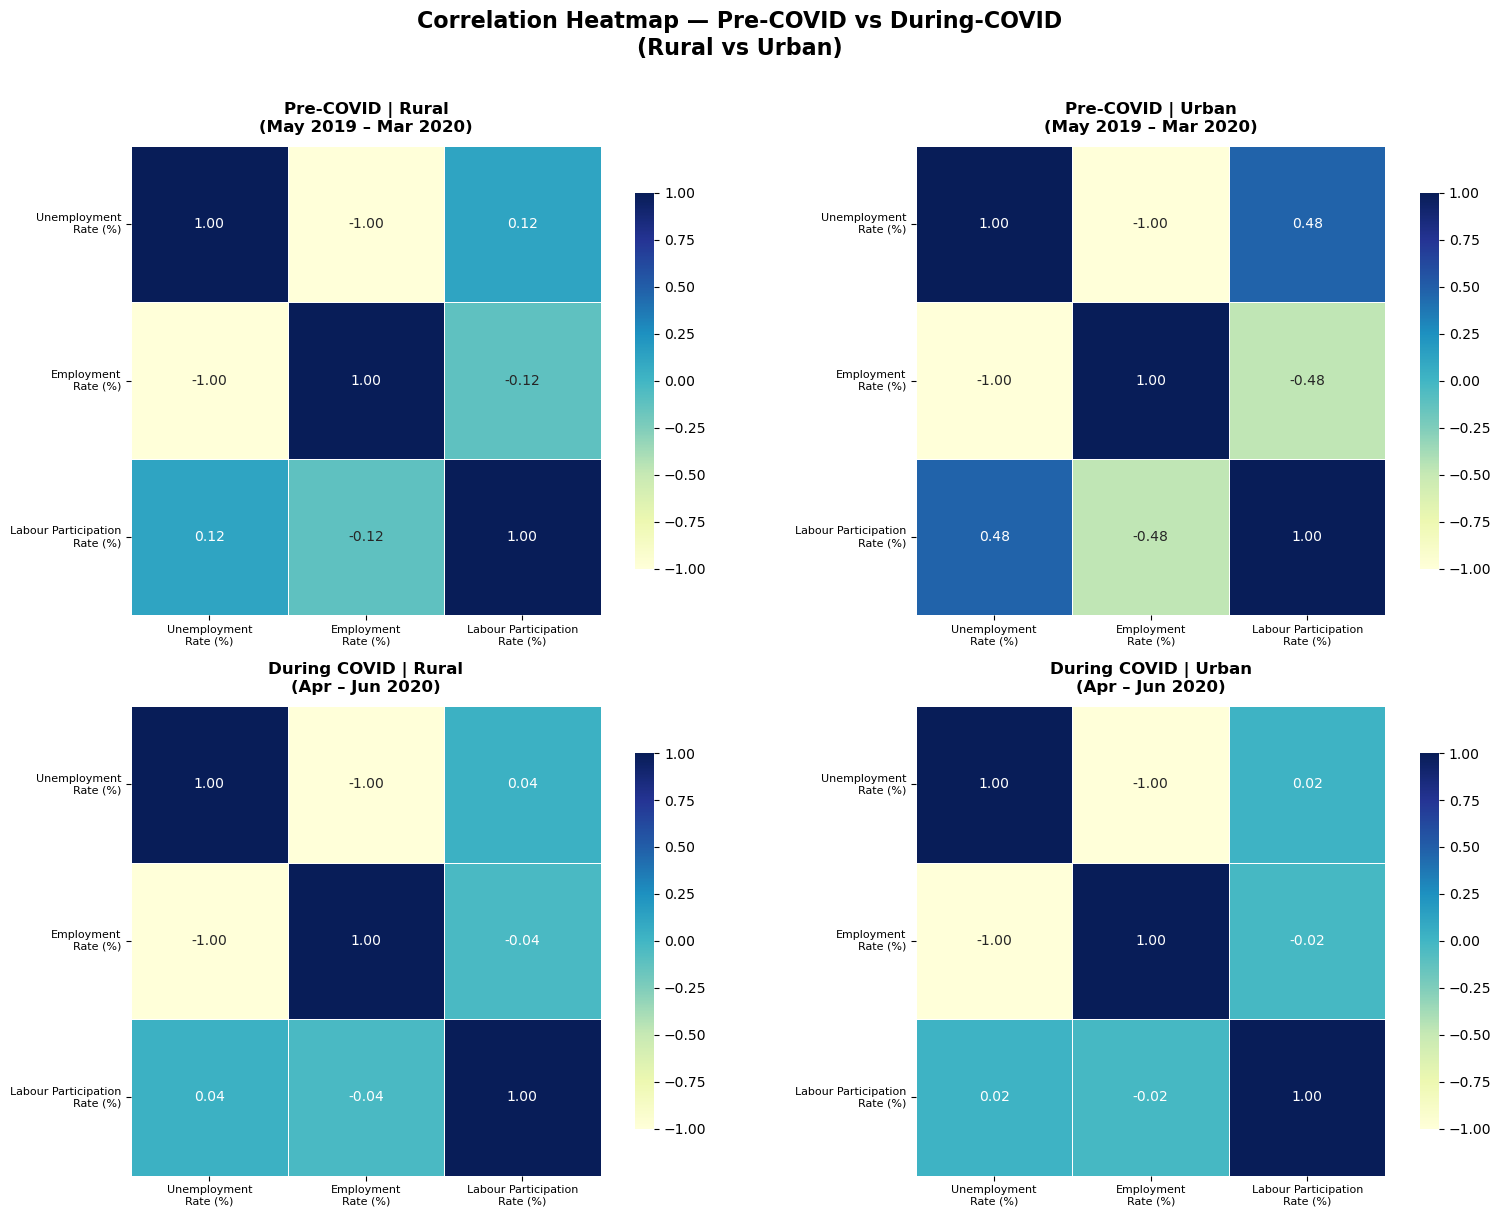

In [62]:
# ── Correlation Heatmap: Pre-COVID vs During-COVID | Rural vs Urban ────────────

temp_df = df.copy()
temp_df['Employment Rate (%)'] = 100 - temp_df['Estimated Unemployment Rate (%)']

corr_cols = ['Estimated Unemployment Rate (%)', 'Employment Rate (%)', 'Estimated Labour Participation Rate (%)']

# Spliting into 4 temp subsets
pre_rural = temp_df[(temp_df['Date'] <  '2020-04-01') & (temp_df['Area'].str.strip() == 'Rural')]
pre_urban = temp_df[(temp_df['Date'] <  '2020-04-01') & (temp_df['Area'].str.strip() == 'Urban')]
covid_rural= temp_df[(temp_df['Date'] >= '2020-04-01') & (temp_df['Area'].str.strip() == 'Rural')]
covid_urban = temp_df[(temp_df['Date'] >= '2020-04-01') & (temp_df['Area'].str.strip() == 'Urban')]

subsets = {
    'Pre-COVID | Rural\n(May 2019 – Mar 2020)' : pre_rural,
    'Pre-COVID | Urban\n(May 2019 – Mar 2020)': pre_urban,
    'During COVID | Rural\n(Apr – Jun 2020)' : covid_rural,
    'During COVID | Urban\n(Apr – Jun 2020)' : covid_urban,
}

# heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Correlation Heatmap — Pre-COVID vs During-COVID\n(Rural vs Urban)',
             fontsize=16, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

short_labels = ['Unemployment\nRate (%)', 'Employment\nRate (%)', 'Labour Participation\nRate (%)']

for ax, (title, subset) in zip(axes_flat, subsets.items()):
    corr = subset[corr_cols].corr()

    sns.heatmap(corr,annot=True,fmt='.2f',cmap='YlGnBu',vmin=-1, vmax=1,square=True,linewidths=0.5,linecolor='white',ax=ax,cbar_kws={'shrink': 0.8},xticklabels=short_labels,yticklabels=short_labels)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('Heatmap_PreCOVID_vs_DuringCOVID_Rural_Urban.png', dpi=150, bbox_inches='tight')
plt.show()


A Observation of correlation Heatmap of **rural** and **urban** socity Before Covid and After Covid 